In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'C:\Users\samue\F-sica-Experimental-II-2024-1-1\Proyecto_Final\DataHallSensor.csv')
print(df)


     0 cm  5 cm  10 cm  15 cm  20 cm  25 cm  30 cm
0     749   746    741    752    748    741    750
1     750   744    750    744    749    748    748
2     750   752    751    743    748    751    750
3     742   753    751    740    744    752    740
4     739   752    743    752    744    743    740
..    ...   ...    ...    ...    ...    ...    ...
274   742   744    749    742    751    751    743
275   740   753    751    742    743    746    739
276   742   752    743    743    743    743    741
277   750   752    744    742    743    741    739
278   749   745    742    748    751    751    749

[279 rows x 7 columns]


**Calculos del campo magnético:**
Los datos que arrojan el sensor hall corresponden a un valor que depende del valor del Vcc, y del campo magnético. Pero no es una medida del campo magnético como tal. El valor que arroja está dado por

$$N = \left ( \frac{V_{cc}}{2} + \frac{1.3\ mV}{Gauss} * B \right) * \frac{1023}{3.3V}$$

Donde Vcc, cuando B = 0, es

$$V_{cc} = 2 * N \left ( 3.3 V / 1023\right) $$

Así, despejando B, tenemos

$$B = \frac{6.6 V * N - 1023 * V_{cc}}{2046*1.3  mV} Gauss.$$

In [8]:
#Calculo de Vcc

N0 = 747

Vcc = 2 * N0 * (3.3 / 1023)

print(Vcc)

4.819354838709677


In [9]:
#Calculo de Campo Magnético

def CampoMagnetico(n):
    return (6.6*n - 1023*Vcc)/(2046*0.0013)

print(CampoMagnetico(3))

df_campo = df.applymap(CampoMagnetico)
print(df_campo)

-1846.1538461538462
          0 cm       5 cm      10 cm      15 cm     20 cm      25 cm  \
0     4.962779  -2.481390 -14.888337  12.406948  2.481390 -14.888337   
1     7.444169  -7.444169   7.444169  -7.444169  4.962779   2.481390   
2     7.444169  12.406948   9.925558  -9.925558  2.481390   9.925558   
3   -12.406948  14.888337   9.925558 -17.369727 -7.444169  12.406948   
4   -19.851117  12.406948  -9.925558  12.406948 -7.444169  -9.925558   
..         ...        ...        ...        ...       ...        ...   
274 -12.406948  -7.444169   4.962779 -12.406948  9.925558   9.925558   
275 -17.369727  14.888337   9.925558 -12.406948 -9.925558  -2.481390   
276 -12.406948  12.406948  -9.925558  -9.925558 -9.925558  -9.925558   
277   7.444169  12.406948  -7.444169 -12.406948 -9.925558 -14.888337   
278   4.962779  -4.962779 -12.406948   2.481390  9.925558   9.925558   

         30 cm  
0     7.444169  
1     2.481390  
2     7.444169  
3   -17.369727  
4   -17.369727  
..         ..

C:\Users\samue\AppData\Local\Temp\ipykernel_1060\602876794.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_campo = df.applymap(CampoMagnetico)


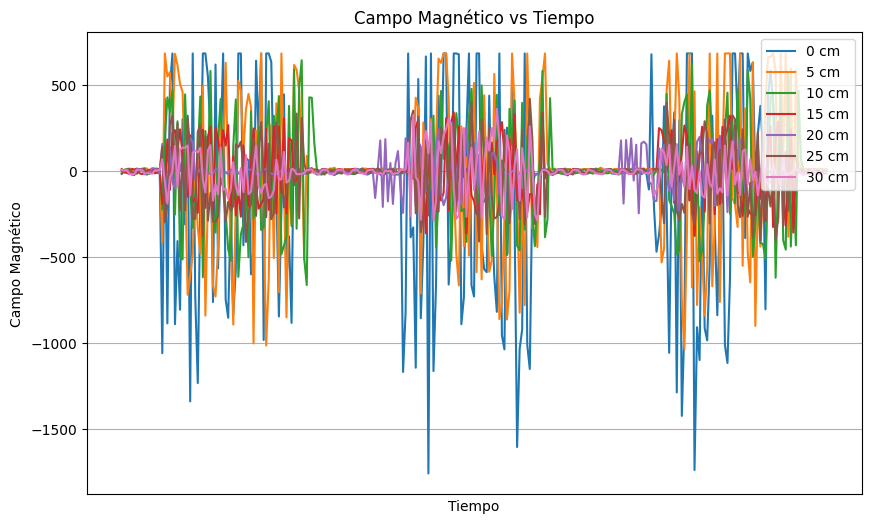

In [10]:
#Gráfica de todas las distancias.

plt.figure(figsize=(10, 6))

# Graficar cada columna
for column in df_campo.columns:
    plt.plot(df_campo[column], label=column)

# Ajustar etiquetas y título
plt.xlabel('Tiempo')
plt.ylabel('Campo Magnético')
plt.title('Campo Magnético vs Tiempo')
plt.legend(loc='upper right')

# Quitar los números del eje x
plt.xticks([])

# Mostrar la gráfica
plt.grid(True)
plt.show()



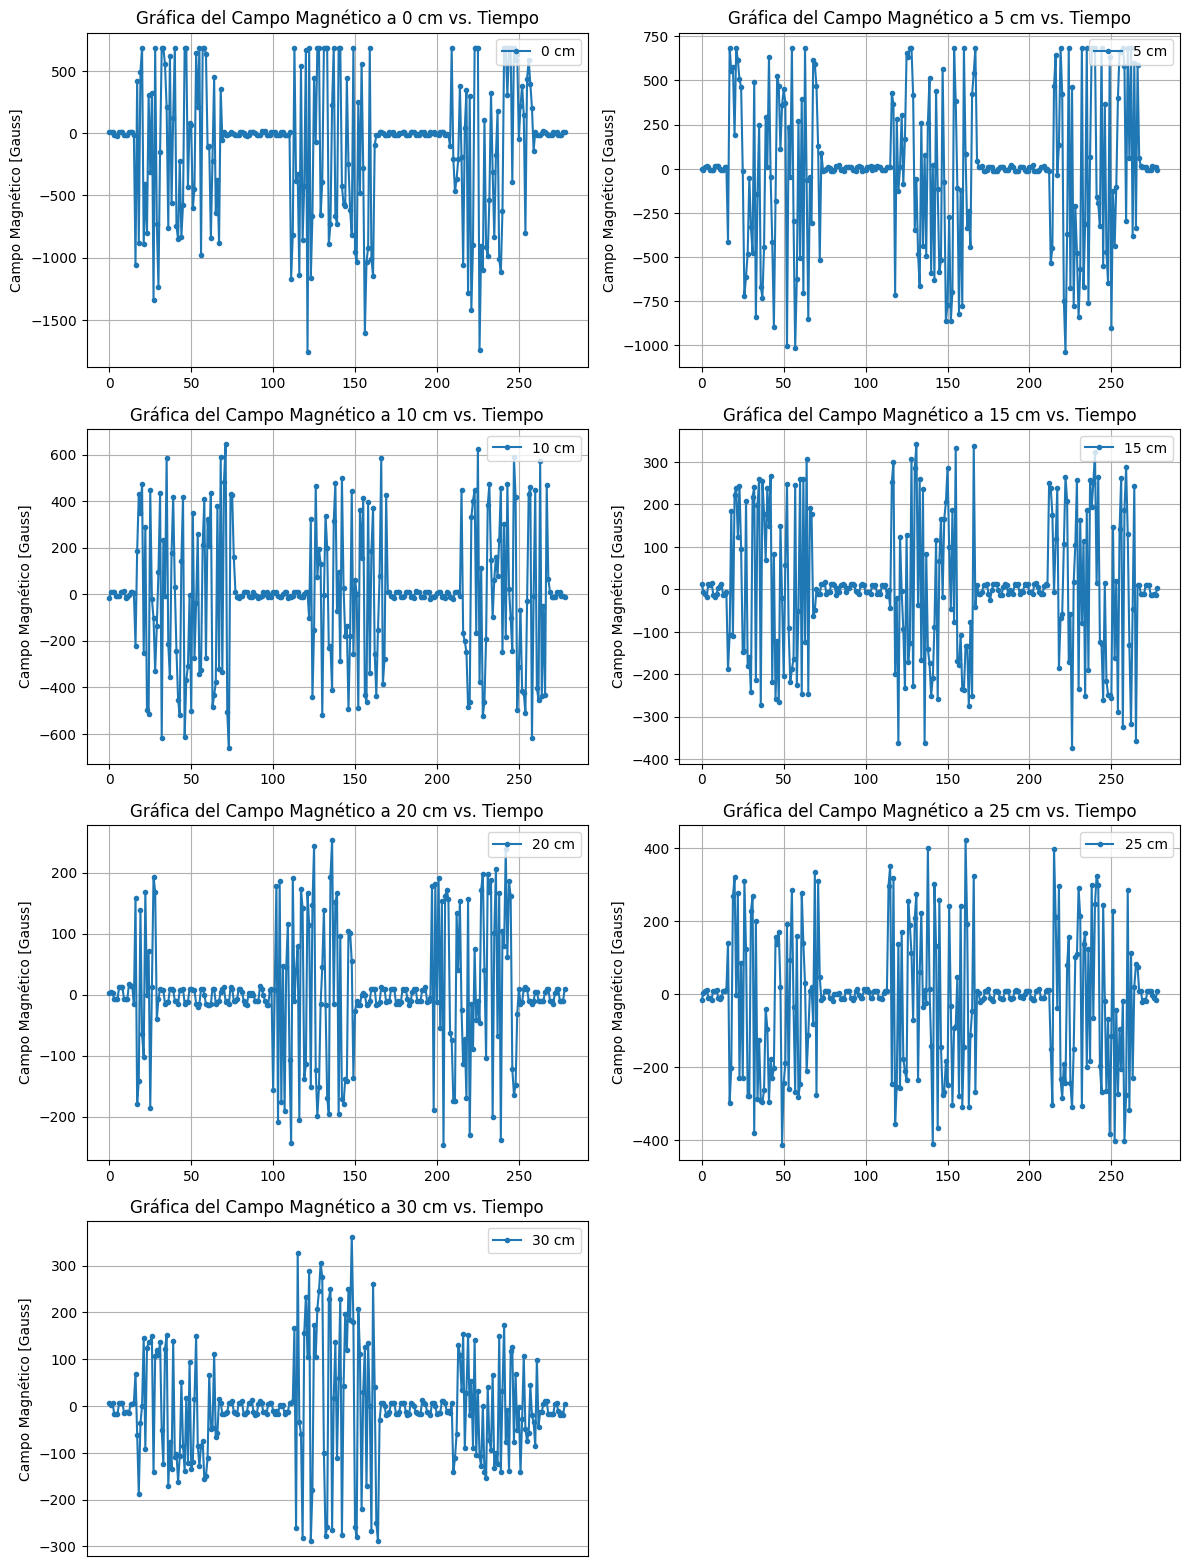

In [11]:
# Crear una figura con 7 subgráficas en 2 columnas
fig, axs = plt.subplots(4, 2, figsize=(12, 16))  # 4 filas, 2 columnas

# Aplanar la matriz de ejes para facilitar la iteración
axs = axs.flatten()

# Grafica cada columna (excepto la columna 'Tiempo')
for i, columna in enumerate(df_campo.columns):
    axs[i].plot(df_campo[columna], marker='o', markersize=3, label=columna)
    axs[i].set_title(f'Gráfica del Campo Magnético a {columna} vs. Tiempo')
    axs[i].set_ylabel('Campo Magnético [Gauss]')
    axs[i].legend(loc='upper right')
    axs[i].grid(True)

# Eliminar subgráficas vacías si hay menos de 8
for i in range(len(df_campo.columns), len(axs)):
    fig.delaxes(axs[i])

# Ajustar el espacio entre subgráficas
fig.tight_layout()

plt.xticks([])
# Muestra la figura
plt.show()

Para darle valor a los campos magnéticos, se va a tomar el promedio del valor absoluto de los datos entre los intervalos de tiempo en el que la bobina esté prendida. (Hecho en Excel)